In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize
%matplotlib inline

In [91]:
data = np.loadtxt("logistic_regression_data.csv",delimiter=',',dtype=np.float64)
X,y= data[:,:-1],data[:,-1].reshape((-1,1))

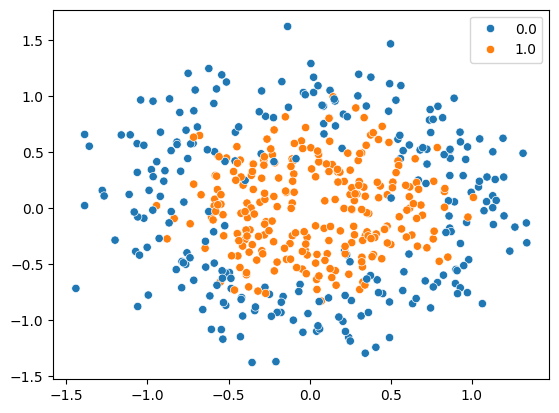

The accuracy is 89.20%


In [92]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y.flatten())
plt.show()


# define the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z)) 

# loss function : log likelihood
def loss(theta,X,y):
    h = sigmoid(np.dot(X,theta))
    cos = -(np.sum(y*np.log(h))+ np.sum((1 - y)*np.log(1 - h)))/len(y)
    return cos

# gradient of the loss
def grad(theta,X,y):
    h = sigmoid(np.dot(X,theta))
    grad = np.dot(X.T,(h-y))/len(y)
    return grad

def expand_feature(x1,x2,power=2):
    # expand a 2D feature matrix to polynomial features up to the power
    new_x =np.ones((x1.shape[0],1))
    for i in range(1,power + 1):
        for j in range(i+1):
            new_x=np.append(new_x,(x1**(i-j)*(x2**j)).reshape(-1,1),axis=1)
    return new_x

def predict(theta,X):
    return (sigmoid(np.dot(X,theta))>0.5).flatten()

def gradient_descent(X,y,theta,alpha,num_iters):
    m=len(y)
    costs=[]
    for _ in range(num_iters):
        h = sigmoid(np.dot(X,theta))
        theta -=alpha * np.dot(X.T,(h-y))/m
        costs.append(loss(theta,X,y))
    return theta,costs

def logistic_regression(X,y,power=2,alpha=0.01,num_iters=100):
    X=expand_feature(X[:,0],X[:,1],power=power)
    theta=np.zeros((X.shape[1],1),dtype=np.float64)
    theta,costs= gradient_descent(X,y,theta,alpha,num_iters)
    predicted = predict(theta,X)
    return predicted,theta,costs

power, num_iters = 2,20000
predicted,theta,costs = logistic_regression(X,y,power=power,alpha=0.6,num_iters=num_iters)

print("The accuracy is {:.2f}%".format(sum(predicted == y.flatten())/len(y)*100))

        


C:\Users\sudsh\AppData\Local\Temp\ipykernel_2516\2867211596.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i,j] = np.dot(expand_feature(point[:,0:1], point[:,1:2], power=power), theta)


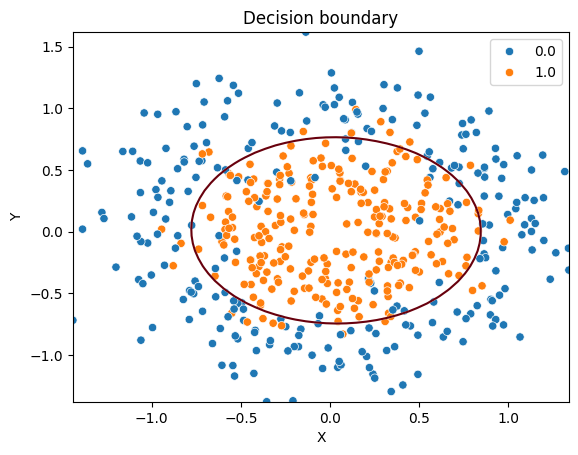

In [93]:
u = np.linspace(min(X[:,0]), max(X[:,0]), 50)
v = np.linspace(min(X[:,1]), max(X[:,1]), 50)

z = np.zeros((len(u), len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        point = np.array([[u[i], v[j]]])  # single point as 2D row
        z[i,j] = np.dot(expand_feature(point[:,0:1], point[:,1:2], power=power), theta)

z = z.T  # transpose for contour

plt.contour(u, v, z, levels=[0, 0.01], cmap="Reds")
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y.flatten())
plt.title("Decision boundary")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


C:\Users\sudsh\AppData\Local\Temp\ipykernel_2516\2285779131.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z[i,j] = np.dot(expand_feature(point[:,0:1], point[:,1:2], power=power), theta)


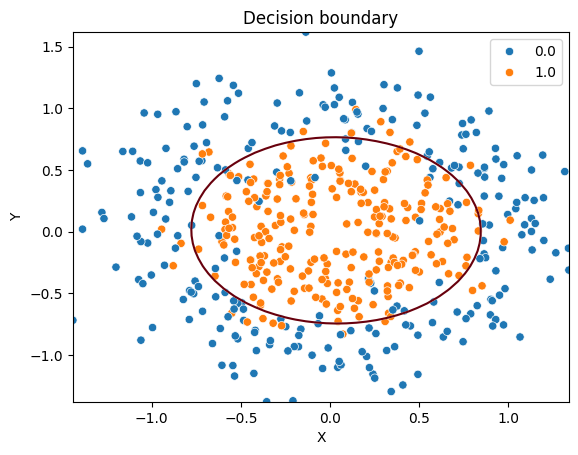

In [94]:
def cost_reg(theta , X , y, lam=0):
    h=sigmoid(np.dot(X,theta))
    theta1=theta.copy()
    theta1[0]=0
    cos = -(np.sum(y*np.log(h))+ np.sum((1 - y)*np.log(1 - h)))/len(y) + lam *np.sum(theta1*theta1)/len(y)
    return cos

def grad_reg(theta,X,y,lam=0):
    h=sigmoid(np.dot(X,theta))
    theta1=theta.copy()
    theta1[0]=0
    grad = (np.dot(X.T,(h - y)) + 2 * lam * theta1)/len(y)
    return grad

def gradient_descent_reg(X,y,theta,alpha,lam=0,num_iters=100):
    m=len(y)
    costs=[]
    for _ in range(num_iters):
        h = sigmoid(np.dot(X,theta))
        theta1=theta.copy()
        theta1[0]=0
        theta -=alpha * np.dot(X.T,(h-y) + 2*lam*theta1)/m
        costs.append(loss(theta,X,y))
    return theta,costs

def logistic_regression_reg(X,y,power=2,alpha=0.1,lam=0,num_iters=100):
    X=expand_feature(X[:,0],X[:,1],power=power)
    theta=np.zeros((X.shape[1],1),dtype=np.float64)
    theta,costs= gradient_descent_reg(X,y,theta,alpha,num_iters)
    predicted = predict(theta,X)
    return predicted,theta,costs

u = np.linspace(min(X[:,0]), max(X[:,0]), 50)
v = np.linspace(min(X[:,1]), max(X[:,1]), 50)

z = np.zeros((len(u), len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        point = np.array([[u[i], v[j]]])  # single point as 2D row
        z[i,j] = np.dot(expand_feature(point[:,0:1], point[:,1:2], power=power), theta)

z = z.T  # transpose for contour

plt.contour(u, v, z, levels=[0, 0.01], cmap="Reds")
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y.flatten())
plt.title("Decision boundary")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
     